<a href="https://colab.research.google.com/github/RahulSwami151/Celebal_2027/blob/main/week2%3CRahul_swami%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AIM :**
# Designed and implemented an end-to-end ML pipeline on sales/price data covering `preprocessing`, `EDA`, `feature engineering`, `regression`,`modeling`, `hyperparameter Tuning`, and `Time Series forecasting`.

In [1]:
#Import all neccesary files
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('tesla_data.csv')

In [3]:
df.shape

(2640, 12)

In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df['Avg_Price_USD'].max()

119965.36

## **STAGE - 1 :**  **Preprocessing**

In [6]:
#let check about null values bcz it can create problem in LinearRegression and XG boost
df.isnull().sum() # No null values

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [7]:
#checking outliers by IQR
features = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD','Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

df_clean = df.copy()
outlier_report = {}

for feature in features:
  Q1,Q3 = df[feature].quantile(0.25) , df[feature].quantile(0.75)
  IQR = Q3-Q1
  lo,ui = Q1 - 1.5*IQR , Q3 + 1.5*IQR
  n_out = ((df_clean[feature] < lo) | (df_clean[feature] > ui)).sum()

  if n_out :
    df_clean[feature] = df_clean[feature].clip(lo,ui)
    outlier_report[feature] = n_out

print(f"\nOutliers clipped: {outlier_report if outlier_report else 'None'}")


Outliers clipped: {'Estimated_Deliveries': np.int64(12), 'Production_Units': np.int64(12), 'CO2_Saved_tons': np.int64(45)}




# **STAGE 2 : EDA**



<Axes: xlabel='Avg_Price_USD', ylabel='Count'>

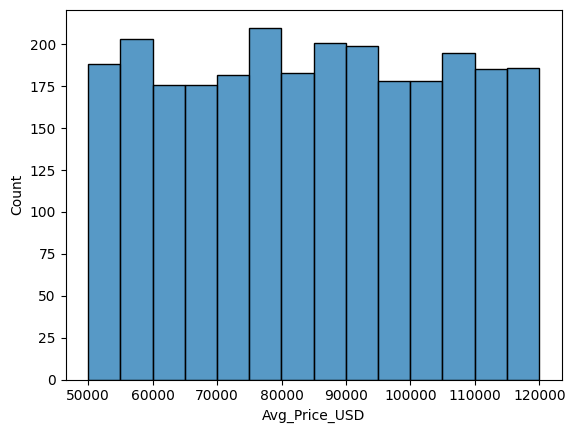

In [8]:
sns.histplot(df["Avg_Price_USD"])

<Axes: xlabel='Region', ylabel='count'>

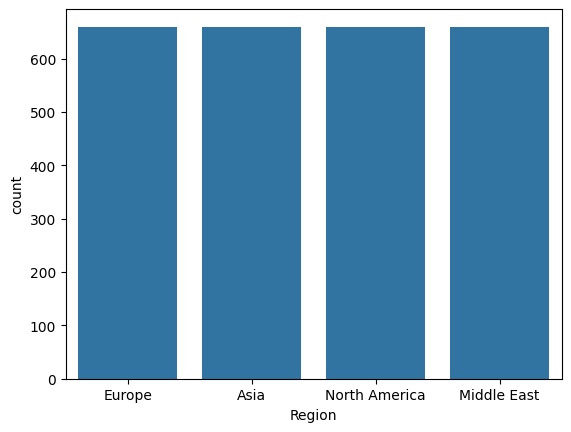

In [9]:
sns.countplot(x=df["Region"]) #Sare same hai

<Axes: >

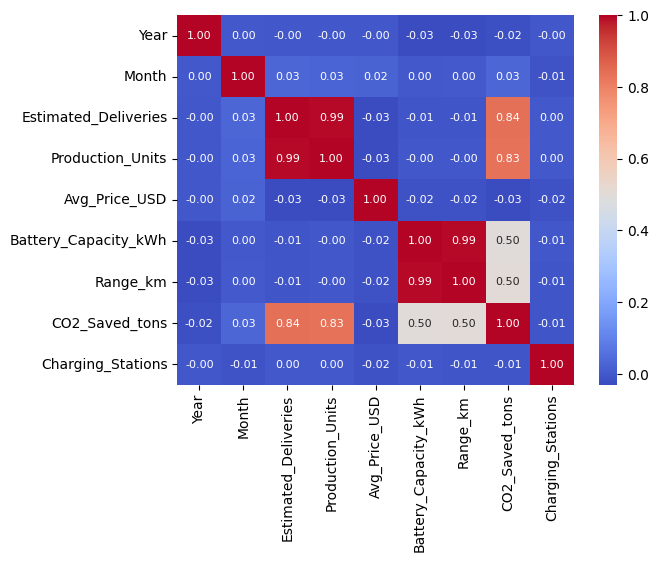

In [10]:
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8}
)

<Axes: xlabel='Avg_Price_USD', ylabel='Estimated_Deliveries'>

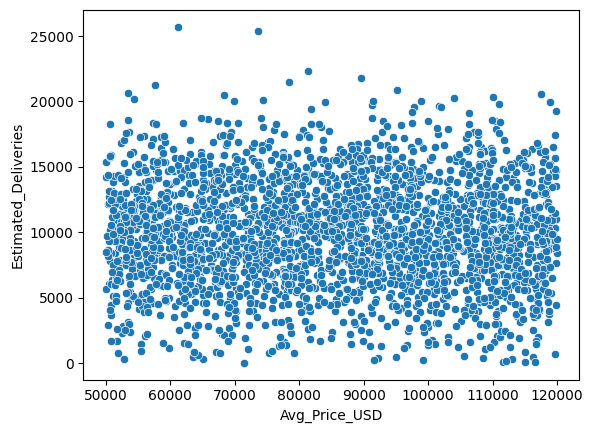

In [11]:
sns.scatterplot(
x="Avg_Price_USD",
y="Estimated_Deliveries",
data=df
)

## **STAGE 3:** **Feature Engineering**

In [12]:
df['Date'] = pd.to_datetime(
    dict(year = df.Year,
         month = df.Month,
         day = 1)
)
df["Quarter"] = df["Date"].dt.quarter
df["Month_sin"] = np.sin(
2*np.pi*df["Month"]/12
)

df["Month_cos"] = np.cos(
2*np.pi*df["Month"]/12
)

In [13]:
df["Price_per_KM"] = (
df["Avg_Price_USD"] /
df["Range_km"]
)

In [14]:
df["Efficiency"] = (
df["Estimated_Deliveries"] /
df["Production_Units"]
)

In [15]:
df["Charging_Density"] = (
df["Charging_Stations"] /
df["Estimated_Deliveries"]
)

**Encoding :** We have some categorical data so we have to convert them into numerical form so we use one hot encoder beacause we have nominal data.

In [16]:
cat_cols = ['Region', 'Model', 'Source_Type']

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = encoder.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols)
)

df_final = pd.concat(
    [df.drop(columns=cat_cols).reset_index(drop=True),
     encoded_df.reset_index(drop=True)],
    axis=1
)

print(df_final.head())

   Year  Month  Estimated_Deliveries  Production_Units  Avg_Price_USD  \
0  2023      5                 17646             17922       92874.27   
1  2015      2                  3797              4164       62205.65   
2  2019      1                  8411              9189      117887.32   
3  2021      2                  6555              7311       89294.91   
4  2016     12                 12374             13537      114846.78   

   Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Charging_Stations  \
0                   120       704         1863.42              12207   
1                    75       438          249.46               7640   
2                    82       480          605.59              14071   
3                   120       712          700.07               9333   
4                   120       661         1226.88               8722   

        Date  ...  Region_Middle East  Region_North America  Model_Cybertruck  \
0 2023-05-01  ...                 0.0          

# **STAGE 4: Regression Model**

In [17]:
df.sample(3)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_sin,Month_cos,Price_per_KM,Efficiency,Charging_Density
1279,2023,7,Middle East,Cybertruck,4551,5027,85436.17,100,551,376.14,Interpolated (Month),14096,2023-07-01,3,-0.5,-8.660254e-01,155.056570,0.905311,3.097341
1286,2020,9,Middle East,Model Y,10233,10752,83140.45,75,435,667.70,Interpolated (Month),13425,2020-09-01,3,-1.0,-1.836970e-16,191.127471,0.951730,1.311932
362,2017,3,Europe,Model X,18358,19736,97573.42,120,664,1828.46,Official (Quarter),6296,2017-03-01,1,1.0,6.123234e-17,146.947922,0.930178,0.342957


In [18]:
X = df_final.drop(["Estimated_Deliveries", "Month", "Date"],axis = 1,errors='ignore')
y = df_final['Estimated_Deliveries']

X_train,X_test,y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **STAGE 5 : Linear Regression**

In [19]:
model = LinearRegression()
model.fit(X_train_scaled ,y_train)

y_pred = model.predict(X_test_scaled)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 2. Print results
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Absolute Error (MAE): $108.83
Root Mean Squared Error (RMSE): $153.61
R-squared (R2 Score): 0.9984


# **Random Forest Regressor**

In [21]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train_scaled,y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Regressor Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_rf:.2f}")
print(f"R-squared (R2 Score): {r2_rf:.4f}")

--- Random Forest Regressor Metrics ---
Mean Absolute Error (MAE): $68.55
Root Mean Squared Error (RMSE): $113.72
R-squared (R2 Score): 0.9991


# **STAGE 6: HYPERPARAMETER TUNING**

In [22]:
# 1. Define the grid of hyperparameters to test
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# 2. Set up the Random Search
# n_iter=10 means it will try 10 random combinations; cv=3 means 3-fold cross-validation
rf_tuned = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1, # Uses all your CPU cores to speed it up
    scoring='neg_mean_absolute_error'
)

# 3. Run the search
rf_tuned.fit(X_train_scaled, y_train)

# 4. Print the best settings found
print("Best Parameters Found:", rf_tuned.best_params_)

Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


In [23]:
best_rf_model = rf_tuned.best_estimator_

# Predict and score
y_pred_final = best_rf_model.predict(X_test_scaled)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_r2 = r2_score(y_test, y_pred_final)

print(f"Tuned Model MAE: ${final_mae:.2f}")
print(f"Tuned Model R2: {final_r2:.4f}")

Tuned Model MAE: $67.15
Tuned Model R2: 0.9991


# **STAGE 7: Time Series Forecasting**

In [24]:
# 1. Group by your engineered 'Date' column to aggregate deliveries chronologically
# We sum the target 'Estimated_Deliveries' and average the numeric features
ts_df = df.groupby('Date').agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum',
    'Avg_Price_USD': 'mean',
    'Battery_Capacity_kWh': 'mean',
    'Range_km': 'mean',
    'Month_sin': 'first',
    'Month_cos': 'first'
}).sort_index()

print(f"Time series dataset shape: {ts_df.shape}")

Time series dataset shape: (132, 7)


In [25]:
# Split on 80% history for training, 20% for future testing
split_idx = int(len(ts_df) * 0.8)

train_ts = ts_df.iloc[:split_idx]
test_ts = ts_df.iloc[split_idx:]

# Separate features (X) and target (y)
X_train_ts = train_ts.drop(columns=['Estimated_Deliveries'])
y_train_ts = train_ts['Estimated_Deliveries']

X_test_ts = test_ts.drop(columns=['Estimated_Deliveries'])
y_test_ts = test_ts['Estimated_Deliveries']

In [26]:
ts_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_depth=None,
    random_state=42
)

# Fit the model sequentially
ts_model.fit(X_train_ts, y_train_ts)

# Generate the forecast
y_forecast = ts_model.predict(X_test_ts)

# Evaluate the forecast performance
mae_ts = mean_absolute_error(y_test_ts, y_forecast)
rmse_ts = np.sqrt(mean_squared_error(y_test_ts, y_forecast))
r2_ts = r2_score(y_test_ts, y_forecast)

print("--- Time Series Forecasting Metrics ---")
print(f"Forecast Mean Absolute Error (MAE): {mae_ts:.2f} deliveries")
print(f"Forecast Root Mean Squared Error (RMSE): {rmse_ts:.2f} deliveries")
print(f"Forecast R2 Score: {r2_ts:.4f}")

--- Time Series Forecasting Metrics ---
Forecast Mean Absolute Error (MAE): 1783.96 deliveries
Forecast Root Mean Squared Error (RMSE): 2212.99 deliveries
Forecast R2 Score: 0.9692


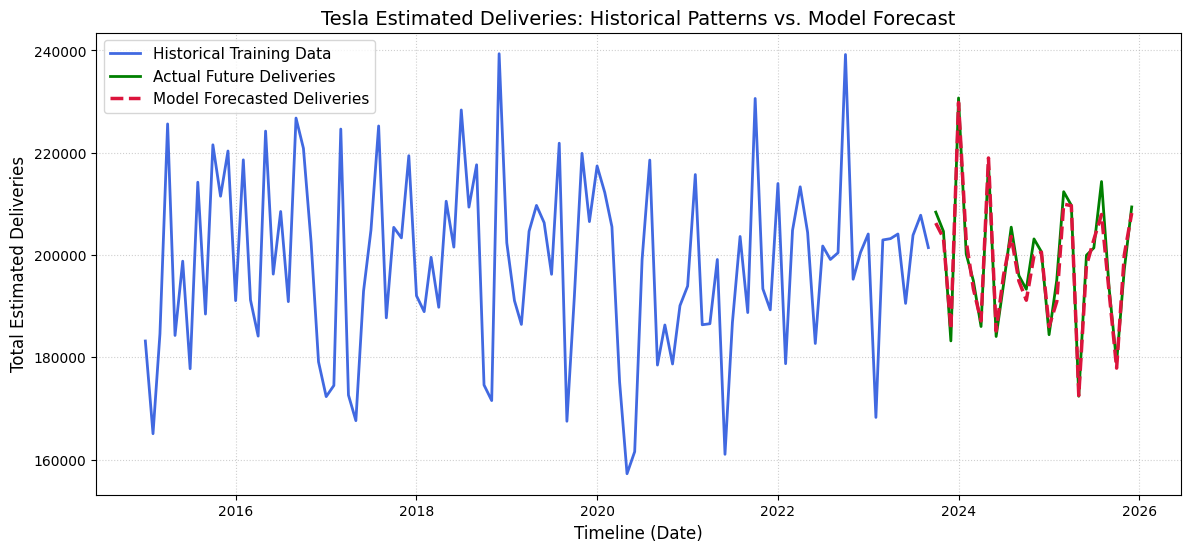

In [27]:
plt.figure(figsize=(14, 6))

# Plot historical training values
plt.plot(y_train_ts.index, y_train_ts, label='Historical Training Data', color='royalblue', linewidth=2)

# Plot actual values in the validation timeline
plt.plot(y_test_ts.index, y_test_ts, label='Actual Future Deliveries', color='emerald' if 'emerald' in plt.colormaps else 'green', linewidth=2)

# Plot your model's forecast line
plt.plot(y_test_ts.index, y_forecast, label='Model Forecasted Deliveries', color='crimson', linestyle='--', linewidth=2.5)

plt.title("Tesla Estimated Deliveries: Historical Patterns vs. Model Forecast", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12)
plt.ylabel("Total Estimated Deliveries", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# **PIPELING**

In [28]:
# 1. Capture the clipping bounds explicitly from your clean dataset logic
features_to_clip = ['Estimated_Deliveries', 'Production_Units', 'CO2_Saved_tons']
clipping_bounds = {}

for feature in features_to_clip:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    clipping_bounds[feature] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# 2. Point to your champion models trained in the notebook
champion_regressor = best_rf_model  # From Stage 6 Hyperparameter Tuning
ts_forecaster = ts_model            # From Stage 7 Time Series

In [29]:
import pickle

# Bind all stages together
pipeline_bundle = {
    'clipping_bounds': clipping_bounds,
    'encoder': encoder,
    'scaler': scaler,
    'categorical_columns': cat_cols,
    'regression_model': champion_regressor,
    'time_series_model': ts_forecaster
}

# Dump the pipeline bundle to a file
with open('tesla_ml_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline_bundle, f)

print("Pipeline successfully bundled and dumped to 'tesla_ml_pipeline.pkl'!")

Pipeline successfully bundled and dumped to 'tesla_ml_pipeline.pkl'!


# **Assingment 2 ✅**